# Post Processing 

In [217]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Keplerian Problem

### Import the CSV file

In [257]:
df = pd.read_csv('kepler_output.csv', comment='#')

t = df["t"].to_numpy()
E = df["E"].to_numpy() 
M = df["M"].to_numpy() 
x = df["x"].to_numpy()
y = df["y"].to_numpy() 
v_K = df["v"].to_numpy()
r = df["r"].to_numpy()
phi = df["phi"].to_numpy() 


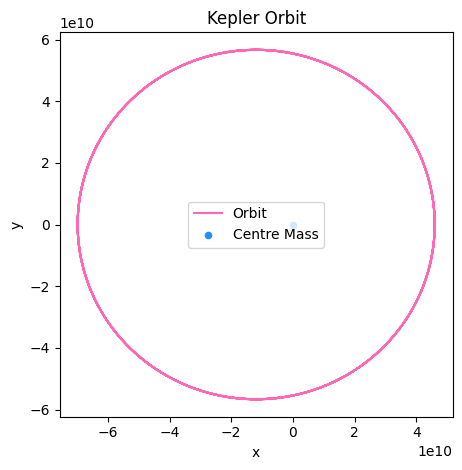

In [251]:
plt.figure() 
plt.plot(x, y, label="Orbit", color = "hotpink")
plt.scatter([0], [0], s=20, label="Centre Mass", color = "dodgerblue") 
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x") 
plt.ylabel("y")
plt.title("Kepler Orbit")
plt.legend() 
plt.tight_layout()
plt.savefig('/Users/macbookair/Desktop/Educational Stuff/BTR/графики/кеплероваорбита.svg')
plt.show() 

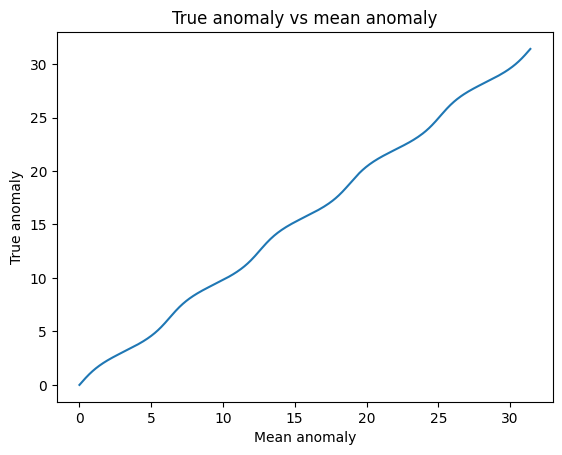

In [252]:
plt.plot(M, phi)
plt.xlabel("Mean anomaly")
plt.ylabel("True anomaly")
plt.title("True anomaly vs mean anomaly")
plt.savefig('/Users/macbookair/Desktop/Educational Stuff/BTR/графики/кеплеровааномалия.svg')
plt.show()

The periodicity is from the orbit completing revolutions from -pi to pi. 

## 1PN Quasi-Keplerian Problem

### Import the CSV file

In [302]:
df = pd.read_csv('1PN_output.csv', comment='#')

t = df["t"].to_numpy()
l = df["l"].to_numpy() 
u = df["u"].to_numpy() 
R = df["R"].to_numpy()
v_1PN = df["v"].to_numpy() 
phi_1PN = df["phi"].to_numpy() 
x = df["x"].to_numpy()
y = df["y"].to_numpy()
import re
k_real = None
Norbits = None
with open("1PN_output.csv", "r") as f:
    for line in f:
        if line.startswith("# k="):
            k_real = float(line.split("=")[1])
        if line.startswith("# Norbits="):
            Norbits = int(float(line.split("=")[1]))  # safe cast
        # stop early once both are found
        if k_real is not None and Norbits is not None:
            break
print("k =", k_real)
print("Norbits =", Norbits)

k = 8.05494495223732e-08
Norbits = 20


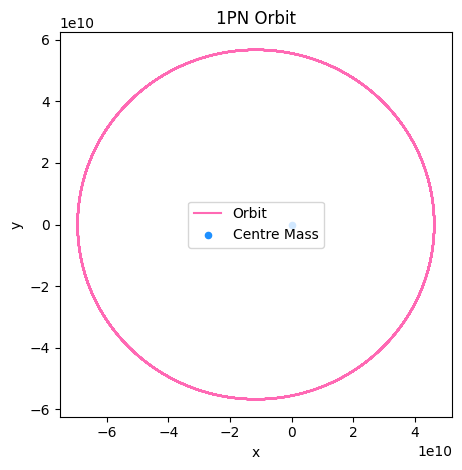

In [303]:
plt.figure() 
plt.plot(x, y, label="Orbit", color = "hotpink")
plt.scatter([0], [0], s=20, label="Centre Mass", color = "dodgerblue") 
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x") 
plt.ylabel("y")
plt.title("1PN Orbit")
plt.legend() 
plt.tight_layout()
plt.savefig('/Users/macbookair/Desktop/Educational Stuff/BTR/графики/1PNорбита.svg')
plt.show() 

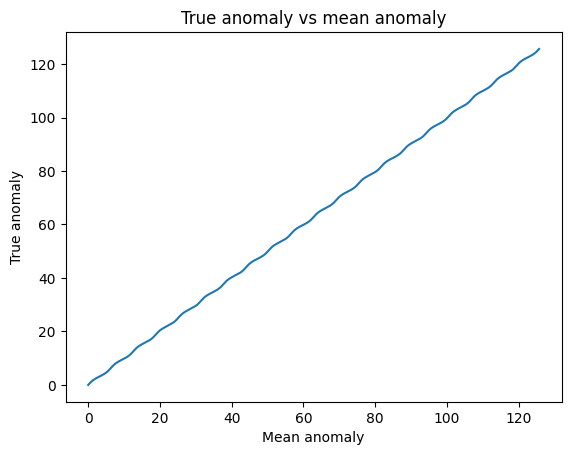

In [304]:
plt.plot(l, phi_1PN)
plt.xlabel("Mean anomaly")
plt.ylabel("True anomaly")
plt.title("True anomaly vs mean anomaly")
plt.savefig('/Users/macbookair/Desktop/Educational Stuff/BTR/графики/1PNорбита.svg')
plt.show()

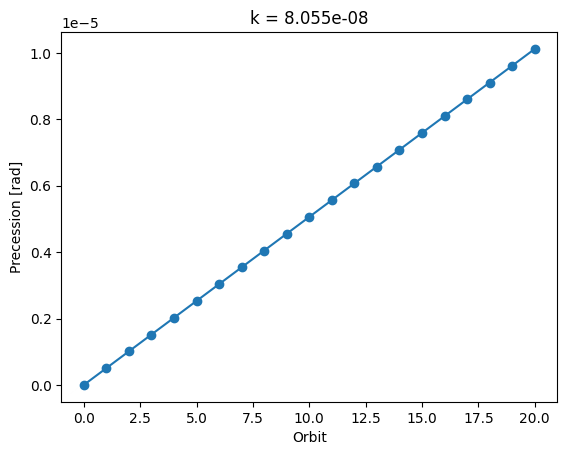

Precession per orbit [rad]: 5.06107117740379e-07
Precession per orbit [arcsec]: 0.10439208658099565
Precession per century [arcsec]: 43.322715931113194


In [317]:
orbit = np.arange(Norbits + 1)
delta_per_orbit = 2*np.pi * k_real
precession = orbit * delta_per_orbit

plt.plot(orbit, precession, 'o-')
plt.xlabel("Orbit")
plt.ylabel("Precession [rad]")
plt.title(f"k = {k_real:.3e}")
plt.show()

print("Precession per orbit [rad]:", delta_per_orbit)
arcsec_per_orbit = delta_per_orbit * (180/np.pi) * 3600
print("Precession per orbit [arcsec]:", arcsec_per_orbit)
arcsec_per_century = arcsec_per_orbit * 415
print("Precession per century [arcsec]:", arcsec_per_century)

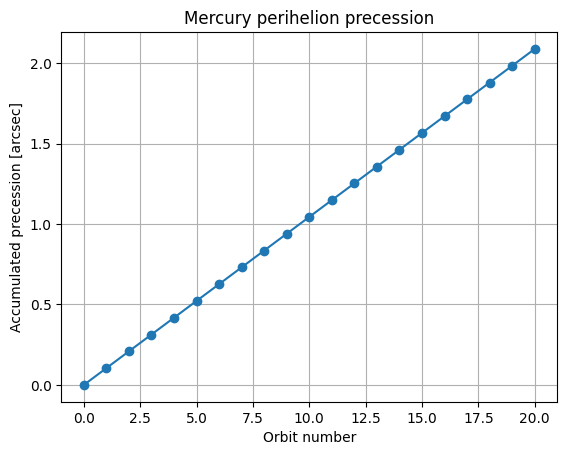

In [318]:
plt.figure()
plt.plot(orbit, precession * (180/np.pi) * 3600, 'o-')
plt.xlabel("Orbit number")
plt.ylabel("Accumulated precession [arcsec]")
plt.title("Mercury perihelion precession")
plt.grid()
plt.show()

## Comparison between phase shift of Keplerian simulation vs 1PN

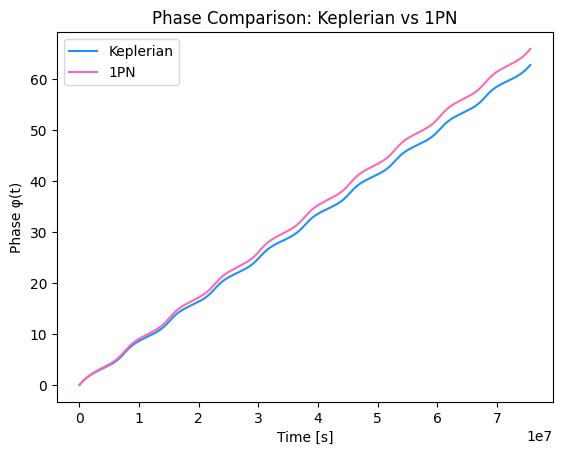

In [192]:
plt.plot(t, phi, label="Keplerian", color = "dodgerblue")
plt.plot(t, phi_1PN, label="1PN", color = "hotpink")
plt.xlabel("Time [s]")
plt.ylabel("Phase φ(t)")
plt.title("Phase Comparison: Keplerian vs 1PN")
plt.legend()
plt.savefig('/Users/macbookair/Desktop/Educational Stuff/BTR/графики/1PNфаза.svg')
plt.show()

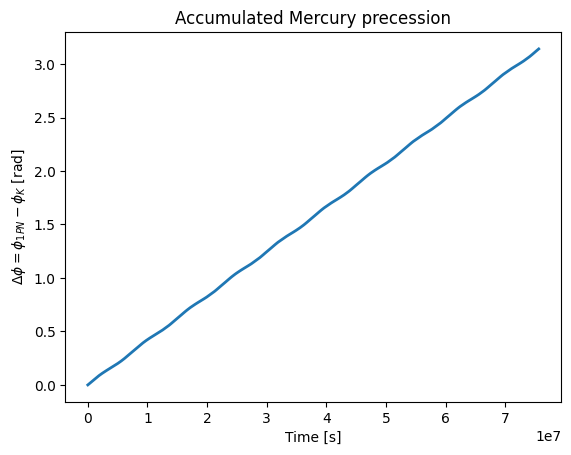

In [193]:
phi = np.unwrap(phi)
phi_1PN = np.unwrap(phi_1PN)

delta_phi = phi_1PN - phi
idx = np.argsort(t)
t = t[idx]
delta_phi = delta_phi[idx]

plt.plot(t, delta_phi, linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel(r"$\Delta\phi = \phi_{1PN}-\phi_K$ [rad]")
plt.title("Accumulated Mercury precession")
plt.show()

## 2PN

In [ ]:
df = pd.read_csv('2PN_output.csv')

t = df["t"].to_numpy()
l = df["l"].to_numpy() 
u = df["u"].to_numpy() 
R = df["R"].to_numpy()
v = df["v"].to_numpy() 
phi = df["phi"].to_numpy() 
x = df["x"].to_numpy()
y = df["y"].to_numpy()

In [ ]:
plt.figure() 
plt.plot(x, y, label="Orbit", color = "hotpink")
plt.scatter([0], [0], s=20, label="Centre Mass", color = "dodgerblue") 
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x") 
plt.ylabel("y")
plt.title("2PN Orbit")
plt.legend() 
plt.tight_layout()
plt.show() 

In [ ]:
plt.plot(l, phi)
plt.xlabel("Mean anomaly")
plt.ylabel("True anomaly")
plt.title("True anomaly vs mean anomaly")
plt.show()